# A/B-тест: редизайн страницы товара (реальные данные)

**Данные:** открытый датасет Kaggle *«A/B Testing — Landing Page»* (`ab_data.csv`,
294 478 событий)

**Продукт:** e-com. **Изменение:** новая версия страницы (`new_page`) против текущей (`old_page`).

**Гипотеза.** Новый дизайн повышает конверсию пользователя в покупку (`converted`).

**Что измеряем.** Единственная метрика в данных бинарная конверсия. Поэтому фокус на
*чистоте эксперимента* и *корректности вывода*

**План**
1. **Аудит и чистка данных**
2. **SRM** 
3. **Primary-метрика**
4. **Мощность / MDE**
5. **Сегментация во времени**
6. **Вывод и решение для продукта.**

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
plt.rcParams['font.family'] = 'DejaVu Sans'   
plt.rcParams['axes.unicode_minus'] = False    

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RNG = np.random.default_rng(7)
N_BOOT = 10_000
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Загрузка и первичный осмотр

In [2]:
df = pd.read_csv("ab_data.csv", parse_dates=["timestamp"])
print("Размер:", df.shape)
print("Период:", df.timestamp.min().date(), "—", df.timestamp.max().date(),
      f"({df.timestamp.dt.date.nunique()} дней)")
df.head()

Размер: (294478, 5)
Период: 2017-01-02 — 2017-01-24 (23 дней)


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
print(df.dtypes, "\n")
print("Пропуски:\n", df.isna().sum(), "\n")
print("Уникальных пользователей:", df.user_id.nunique(), "из", len(df), "строк")
print("Группы:", df.group.unique(), "| Страницы:", df.landing_page.unique())

user_id                  int64
timestamp       datetime64[ns]
group                   object
landing_page            object
converted                int64
dtype: object 

Пропуски:
 user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64 

Уникальных пользователей: 290584 из 294478 строк
Группы: ['control' 'treatment'] | Страницы: ['old_page' 'new_page']


## 2. Аудит качества данных

Прежде чем считать конверсию, проверяем целостность назначения. Логика эксперимента:
`control` обязан видеть `old_page`, `treatment` видеть `new_page`. Любое нарушение означает,
что пользователь попал «не в свою» ветку, и такие строки искажают сравнение

In [4]:
xtab = pd.crosstab(df.group, df.landing_page)
print(xtab, "\n")

mismatch = df[((df.group == "treatment") & (df.landing_page == "old_page")) |
              ((df.group == "control")   & (df.landing_page == "new_page"))]
print(f"Несогласованных строк: {len(mismatch):,} ({len(mismatch)/len(df):.2%})")

landing_page  new_page  old_page
group                           
control           1928    145274
treatment       145311      1965 

Несогласованных строк: 3,893 (1.32%)


Несогласованных строк: 3,893 (1.32%)


In [5]:
# Удаляем нарушившие целостность строки
clean = df.drop(mismatch.index).copy()
print(f"После удаления рассинхрона: {len(clean):,} строк")

# Дубликаты пользователей (один user_id — несколько событий)
dups = clean.user_id.value_counts()
print("Пользователей с >1 событием:", (dups > 1).sum())
clean = clean.drop_duplicates(subset="user_id", keep="first")
print(f"После дедупликации: {len(clean):,} строк, уникальных юзеров: {clean.user_id.nunique():,}")

После удаления рассинхрона: 290,585 строк
Пользователей с >1 событием: 1
После дедупликации: 290,584 строк, уникальных юзеров: 290,584


## 3. Проверка сплита: SRM

Сначала убедимся, что после чистки трафик распределён ожидаемо 50/50. Пока SRM не пройден,
сравнивать конверсию нельзя.

In [6]:
counts = clean.group.value_counts().reindex(["control", "treatment"])
chi2, p_srm = stats.chisquare(counts.values, [counts.sum()/2]*2)
print(counts.to_string())
print(f"Доля treatment: {counts['treatment']/counts.sum():.4f}")
print(f"chi2 = {chi2:.3f}, p = {p_srm:.4f}")
print("Вывод:", "SRM не выявлен, сплит корректен" if p_srm > 0.01
      else "SRM! сплит сломан")

group
control      145274
treatment    145310
Доля treatment: 0.5001
chi2 = 0.004, p = 0.9468
Вывод: SRM не выявлен, сплит корректен


## 4. Primary-метрика: конверсия

z-тест долей для значимости и **бутстрэп**-доверительный интервал разницы
(без допущений о распределении)

In [12]:
def bootstrap_diff(a, b, n_boot=N_BOOT, rng=RNG, batch=500):
    """Бутстрэп-распределение разницы средних (b - a). Для бинарных = разница долей."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    na, nb = len(a), len(b)
    out = []
    for s in range(0, n_boot, batch):
        k = min(batch, n_boot - s)
        ia = rng.integers(0, na, size=(k, na))
        ib = rng.integers(0, nb, size=(k, nb))
        out.append(b[ib].mean(1) - a[ia].mean(1))
    return np.concatenate(out)

c = clean.loc[clean.group == "control",   "converted"].values
t = clean.loc[clean.group == "treatment", "converted"].values
p_c, p_t = c.mean(), t.mean()
abs_lift, rel_lift = p_t - p_c, (p_t - p_c) / p_c

z, pval = proportions_ztest([t.sum(), c.sum()], [len(t), len(c)])
boot = bootstrap_diff(c, t)
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f"конверсия control:   {p_c:.4f}")
print(f"конверсия treatment: {p_t:.4f}")
print(f"абс. лифт: {abs_lift:+.4f} | отн. лифт: {rel_lift:+.2%}")
print(f"z-тест долей: z={z:.3f}, p={pval:.4f}")
print(f"бутстрэп 95% ДИ разницы: [{lo:+.4f}; {hi:+.4f}]")
print("Вывод:", "значимо" if (lo > 0 or hi < 0) else "НЕ значимо, эффекта не видно")

конверсия control:   0.1204
конверсия treatment: 0.1188
абс. лифт: -0.0016 | отн. лифт: -1.31%
z-тест долей: z=-1.311, p=0.1899
бутстрэп 95% ДИ разницы: [-0.0039; +0.0008]
Вывод: НЕ значимо, эффекта не видно


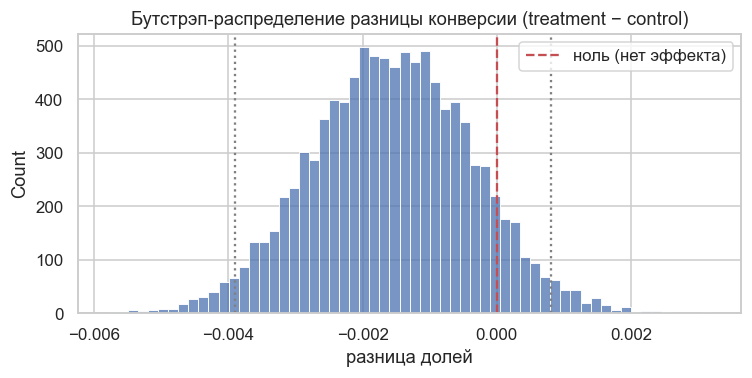

In [25]:
fig, ax = plt.subplots(figsize=(7, 3.6))
sns.histplot(boot, bins=60, color="#4C72B0", ax=ax)
ax.axvline(0, color="#C44E52", ls="--", lw=1.5, label="ноль (нет эффекта)")
ax.axvline(lo, color="grey", ls=":"); ax.axvline(hi, color="grey", ls=":")
ax.set_title("Бутстрэп-распределение разницы конверсии (treatment − control)")
ax.set_xlabel("разница долей"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Мощность и MDE

«Различий нет» имеет смысл только если эксперимента хватало, чтобы поймать
практически значимый эффект. Считаем минимально детектируемый эффект (MDE) при
текущем размере выборки, α=0.05 и мощности 80%

In [15]:
from scipy.optimize import brentq
n_grp = int(counts.min())
analysis = NormalIndPower()

def power_at(p1):
    es = proportion_effectsize(p1, p_c)
    return analysis.power(effect_size=es, nobs1=n_grp, alpha=0.05,
                          ratio=1.0, alternative="two-sided")

p1_mde = brentq(lambda p1: power_at(p1) - 0.8, p_c + 1e-5, p_c + 0.03)
print(f"n на группу: {n_grp:,} | базовая конверсия: {p_c:.4f}")
print(f"MDE при мощности 80%: до {p1_mde:.4f} "
      f"(абс. {p1_mde - p_c:+.4f}, отн. {(p1_mde - p_c)/p_c:+.2%})")
print(f"Наблюдаемый эффект: {abs_lift:+.4f} — внутри шума.")

n на группу: 145,274 | базовая конверсия: 0.1204
MDE при мощности 80%: до 0.1238 (абс. +0.0034, отн. +2.83%)
Наблюдаемый эффект: -0.0016 — внутри шума.


Тест отмощнён: лифт хотя бы ~+0.34 пп мы бы увидели. но его нет

## 6. Сегментация во времени

Проверяем, не прячется ли эффект в отдельных днях недели и нет ли эффекта новизны

In [29]:
from matplotlib.font_manager import FontProperties, findfont

# смотрим, какой шрифт реально подхватывается прямо сейчас
fp = FontProperties(family="DejaVu Sans")
print(findfont(fp))

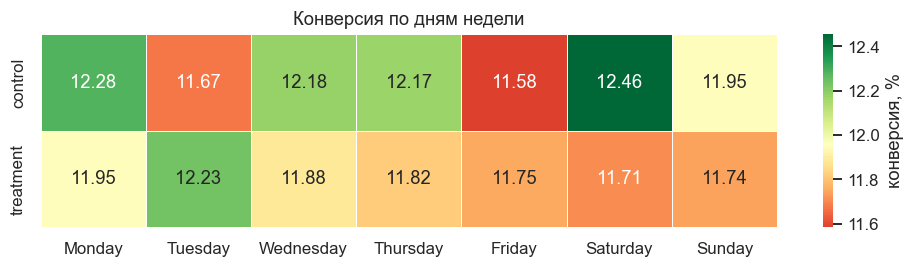

In [28]:
clean = clean.assign(dow=clean.timestamp.dt.day_name(),
                     date=clean.timestamp.dt.date)
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
heat = (clean.groupby(["group","dow"])["converted"].mean()
              .unstack("dow").reindex(columns=order)) * 100

plt.figure(figsize=(9, 2.6))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdYlGn", center=heat.values.mean(),
            cbar_kws={"label": "конверсия, %"}, linewidths=.5)
plt.title("Конверсия по дням недели")
plt.ylabel(""); plt.xlabel("")
plt.tight_layout(); plt.show()

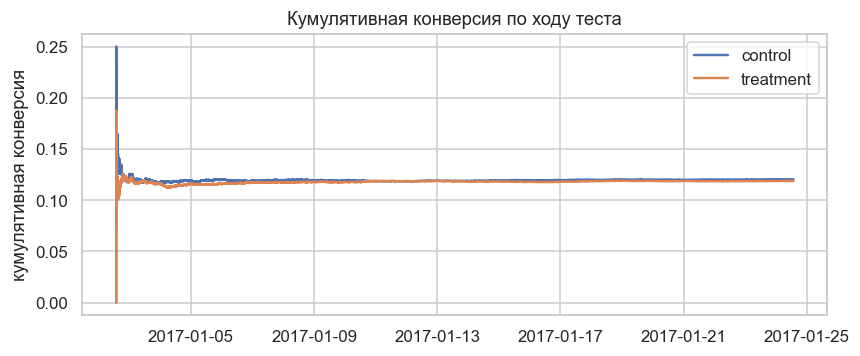

In [24]:
# Эффект новизны: кумулятивная конверсия по дням эксперимента
daily = (clean.groupby(["date","group"])["converted"].mean().unstack("group")
              .sort_index())
cum = (clean.sort_values("timestamp")
            .assign(one=1)
            .groupby("group")
            .apply(lambda g: pd.Series(g.converted.cumsum().values / g.one.cumsum().values,
                                       index=g.timestamp))
       )
fig, ax = plt.subplots(figsize=(8, 3.4))
for grp, color in [("control", "#4C72B0"), ("treatment", "#DD8452")]:
    s = cum.loc[grp]
    ax.plot(s.index, s.values, label=grp, color=color, lw=1.6)
ax.set_title("Кумулятивная конверсия по ходу теста")
ax.set_ylabel("кумулятивная конверсия"); ax.legend()
plt.tight_layout(); plt.show()

## 7. Выводы и решение

**Качество данных.** В сырых данных ~1.3% строк нарушали целостность назначения
(`treatment` видел старую страницу и наоборот) плюс дубликаты пользователей. Без этой
чистки сравнение было бы смещённым

**Корректность эксперимента.** После чистки **SRM пройден** (p ≈ 0.95), сплит ровно 50/50.

**Результат.** Конверсия: **control 12.04% vs treatment 11.88%**, разница **−0.16 пп**
(p ≈ 0.19). Бутстрэп-ДИ разницы накрывает ноль, **статистически значимого эффекта нет**.
Точечная оценка даже слегка отрицательная

**Это надёжный ноль, а не нехватка данных.** При ~145 тыс. пользователей на группу тест
ловил бы лифт от **+0.34 пп (+2.8%)** с мощностью 80%. Такого улучшения нет ни в среднем,
ни по дням недели, ни в динамике (эффекта новизны не видно)

**Рекомендация продукту**
1. **Новую страницу не катить**, так как она не улучшает конверсию, а риск лёгкого падения есть.
2. Сэкономленный трафик направить на **более смелую гипотезу**: текущий редизайн, видимо,
   слишком косметический, чтобы сдвинуть поведение.
3. Перед следующим тестом**зафиксировать целостность назначения на стороне сплит-системы**,
   чтобы не терять 1.3% данных на рассинхроне.
4. Добавить в сбор данных выручку/чек: на одной бинарной конверсии нельзя поймать эффекты,
   которые двигают деньги, но не конверсию
